# RNN Hindi Translator

## Stack
- **Framework**: PyTorch (with `torch.utils.data` for batching)
- **Tokenization**: `indic-nlp-library` for Hindi (Devanagari-aware), simple regex/whitespace for English. Optional upgrade: `sentencepiece` BPE later.
- **Eval metric**: `sacrebleu` for BLEU scoring
- **Plotting**: `matplotlib` for loss curves and attention heatmaps
- **Environment**: Colab notebook with GPU runtime enabled (`Runtime → Change runtime type → T4 GPU`)

Note: this is not how it turned out.

## Plan
(Note: `<sos>` means start of sequence. `<eos>` means end of sequence. `<pad>` is for padding. `<unk>` is for unknown words.)

### Data Pipeline
- Use Hindi-English Truncated Corpus from Kaggle.
- Upload csv via files.upload()
- Lowercase English
- Strip URLs, HTML, non-Devangari/Latin junk
- Drop pairs where either side is empty or length ratio > 3:1
- Drop pairs where either side > ~30 tokens
- Tokenization for Hindi: `indic_nlp_library.tokenize.indic_tokenize.trivial_tokenize(text, lang='hi')`
- Tokenization for English: `nltk.word_tokenize` (could also use `.lower().split()`)
- Build two `Vocab` objects (one per language) mapping tokens → integer IDs. Reserved indices:
* `<pad>` = 0
* `<sos>` = 1
* `<eos>` = 2
* `<unk>` = 3
- Cap vocab at ~15k–20k most frequent tokens per side (rare words → `<unk>`).
- `TranslationDataset` returning `(hi_tensor, en_tensor)` with `<sos>` and `<eos>` wrapped
- `collate_fn` that pads to the longest sequence in the batch using `torch.nn.utils.rnn.pad_sequence`
- Batch size 32–64 for T4
- Train/test split 90/10

### Phase A — Vanilla Seq2Seq
Simplest thing first. No attention, no bidirectional encoder.
- Encoder:
`nn.Embedding(hi_vocab_size, emb_dim=256)`
`nn.GRU(emb_dim, hidden_dim=512, num_layers=1, batch_first=True)`
Tweak with the parameters above of course.
Forward returns the final hidden state.
This is the context vector bottleneck because we compress all of the sentence into the hidden_dim.

- Decoder:
`nn.Embedding(en_vocab_size, emb_dim=256)`
`nn.GRU(emb_dim, hidden_dim=512, num_layers=1, batch_first=True)`
`nn.Linear(hidden_dim, en_vocab_size)`
Initialized with the encoder's final hidden state.
Steps one token at a time during inference.
Can run the whole target sequence in parallel during training (with teacher forcing).

- Training Loop:
Loss: `nn.CrossEntropyLoss(ignore_index=PAD_IDX)`
Optimizer: Adam, lr=1e-3
Teacher forcing ratio: 0.5 sample per timestep
Gradient clipping: `torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)`
Epochs: 10-20
Log train/test loss per epoch, save the best model by testloss using a checkpointing function

Expect: translate short sentences, but fails on long one.
Record some bad examples to compare with Phase B.

### Phase B — Seq2Seq with Attention
- Make the encoder bidirectional
`nn.GRU(emb_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=True)`
Returns outputs of shape `(batch_dim, seq_len, 2*hidden_dim)`
Project the concatenated final state down to `hidden_dim` with `nn.Linear`to initialize the decoder.

- Add attention.

- Update decoder
At each step:
1. Compute attention weights using current decoder hidden state + all encoder outputs
2. Compute context vector as weighted sum of encoder outputs
3. Concatenate `[embed(prev_token), context]` → feed to GRU
4. Concatenate `[gru_output, context]` → linear → vocab logits

Keep attention weighs to visualize as heatmaps to confirm the model learns to look at Hindi verb position when emitting the English verb

Expected: better translation on longer sentences.
Attention heatmaps should show SOV to SVO reordering.

### Phase C — Polishing
After Phase B works end-to-end.
- Beam search decoder (beam width 3–5) — implement as a separate function, not a replacement; keep greedy for fast eval
- Scale to IITB corpus — re-run the same pipeline with the full 1.5M pairs (a bigger Colab session or Kaggle GPU). Same code, more data, longer training.
- BPE tokenization via `sentencepiece` to handle OOV better
- Learning rate scheduling (`ReduceLROnPlateau` on val loss)
- Write detokenize_en function to join punctuation back together.

### Verification
End-to-end checks (run each at the end of its phase):
After Phase 1 (data):
- Print 5 random `(hi, en)` pairs from the DataLoader, decoded back to text via vocab — confirm tokenization isn't garbling Devanagari
- Print vocab sizes and a histogram of sentence lengths

After Phase 2 (vanilla):
- Train loss should decrease steadily; val loss should plateau (some overfitting is expected with no attention)
- Translate ~10 held-out sentences manually; expect short sentences (3–5 words) to be reasonable and long ones to be garbled
- Compute BLEU on the val set with `sacrebleu` — expect something low (5–15)

After Phase 3 (attention):
- Same 10 held-out sentences should translate noticeably better
- BLEU should jump (target: 20+ on the small dataset)
- Render attention heatmaps for 2–3 example translations using `matplotlib.imshow` on the saved attention weights — confirm visible diagonal-ish pattern with SOV→SVO flips

Quick translations to try once trained:
- `मैं स्कूल जाता हूँ` → "I go to school"
- `वह सेब खाता है` → "He eats apples" (SOV→SVO flip)
- A longer 10+ word sentence to stress-test


### Future Updates
- Make this with a transformer
- Deploy to HuggingFace
- search for APIs and other ways to make this all go by quicker after done creating.


# Setup & Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

import pandas as pd
import nltk
nltk.download('punkt_tab')   # needed by nltk.word_tokenize on recent nltk versions

import matplotlib.pyplot as plt
import re

from tqdm.auto import tqdm

from collections import Counter

import os
import random

# import devanagari fonts for visualization reasons
!apt-get install -y -qq fonts-noto-core
import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.__init__()
matplotlib.rcParams['font.family'] = ['Noto Sans Devanagari', 'DejaVu Sans']
deva_fonts = [f.name for f in fm.fontManager.ttflist if 'Devanagari' in f.name]
print('Found Devanagari fonts:', deva_fonts)


cuda


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Found Devanagari fonts: ['Noto Sans Devanagari', 'Noto Serif Devanagari', 'Noto Serif Devanagari', 'Noto Sans Devanagari']


In [2]:
!pip install indic_nlp_library sacrebleu
from indicnlp.tokenize import indic_tokenize
import sacrebleu

# Data Download & Inspection

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Load the data
CSV_PATH = '/content/drive/MyDrive/rnn-translator/Hindi_English_Truncated_Corpus.csv'
df = pd.read_csv(CSV_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Inspect data
print(f"Shape: {df.shape}")
print(f"Head: {df.head()}")
print(f"Tail: {df.tail()}")

Shape: (127607, 3)
Head:       source                                   english_sentence  \
0        ted  politicians do not have permission to do what ...   
1        ted         I'd like to tell you about one such child,   
2  indic2012  This percentage is even greater than the perce...   
3        ted  what we really mean is that they're bad at not...   
4  indic2012  .The ending portion of these Vedas is called U...   

                                      hindi_sentence  
0  राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर...  
1  मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...  
2   यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।  
3     हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते  
4        इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।  
Tail:            source                                   english_sentence  \
127602  indic2012  Examples of art deco construction can be found...   
127603        ted                          and put it in our cheeks.   
127604      tides  A

In [5]:
print(f"Number of missing vals per col: {df.isnull().sum()}")
print(f"Source distribution:\n {df['source'].value_counts()}")

Number of missing vals per col: source              0
english_sentence    2
hindi_sentence      0
dtype: int64
Source distribution:
 source
tides        50000
ted          39881
indic2012    37726
Name: count, dtype: int64


In [6]:
print(f"English min, max, mean, percentile: {df['english_sentence'].str.split().str.len().describe()}")
print(f"Same for Hindi: {df['hindi_sentence'].str.split().str.len().describe()}")

English min, max, mean, percentile: count    127605.000000
mean         16.091815
std          14.453657
min           1.000000
25%           7.000000
50%          12.000000
75%          21.000000
max         398.000000
Name: english_sentence, dtype: float64
Same for Hindi: count    127607.000000
mean         17.887522
std          16.560262
min           1.000000
25%           8.000000
50%          13.000000
75%          24.000000
max         418.000000
Name: hindi_sentence, dtype: float64


What data inspection indicates:
1. Two missing English sentences
2. Sources are about balanced.
3. English median length of 12, p75 is 21, max of 398.
4. Hindi median of 13, p75 is 24, max of 418. Massive p75 to max gaps for both!

In [7]:
# Get the ten rows with the smallest tokens for english & display
df.assign(en_len=df['english_sentence'].str.split().str.len()).nsmallest(10, 'en_len')[['english_sentence', 'hindi_sentence']]
# We want to eyeball the extremes to see if filters will catch them

,english_sentence,hindi_sentence
33,Maine,मेन
124,.Masterbation,मैथुन
189,amazing.,कमाल है.
244,Muzaffarpur,मुजफ्फरपुर
291,Tamil,तमिळ
297,Riva,रीवा
306,Nevada,नेवाडा
315,one-upmanship.,होड़ चली है.
330,(Laughter),(ठहाके)
445,Sangini(Saturday),संगिनी (शनिवार)


In [8]:
# Ditto but now largest
df.assign(en_len=df['english_sentence'].str.split().str.len()).nlargest(10, 'en_len')[['english_sentence', 'hindi_sentence']]

,english_sentence,hindi_sentence
97324,We cannot appreciate the classical music unles...,हम तब तक क्लासिकल म्यूजिक को नहीं समझ सकते जब ...
103551,"In 1598,[9] a court case referred to a sport c...",क्रिकेट शब्द के लिए शब्दों की संख्या सक्भव स्र...
121987,We cannot undestand classical music unless and...,हम तब तक क्लासिकल म्यूजिक को नहीं समझ सकते जब ...
70199,As with “”terrorism“” the concept of “”state t...,राज्य आतंकवाद की अवधारणा विवादास्पद है .राज्यो...
75123,Missionery position is the most popular and tr...,मिशनरी पोजीशन सर्वाधिक प्रचलित और पारंपरिक सेक...
114935,The idea of adding text messaging to the servi...,मोबाइल फोन ग्राहकों प्रति 100 निवासि 1997-2007...
112676,Missionary position is the most common and tra...,मिशनरी पोजीशन सर्वाधिक प्रचलित और पारंपरिक सेक...
37097,".As is clear from the name, in this the lady d...",जैसा की नाम से ही स्पष्ट है इसमें महिला ऐसा व्...
79015,The pejorative connotations of the word can be...,शब्द का अपमानजनक कोन्नोताशन्स इस मेंसब जुड़ गय...
125955,The origins of the Defense Logistics Agency (D...,जानबूझकर गैर का लक्ष्यीकरण-लड़ाकों - यह सामान्...


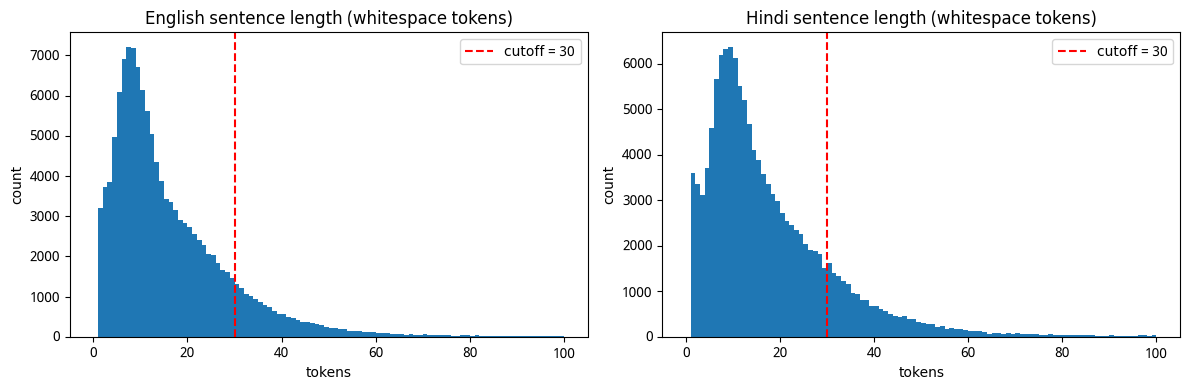

In [9]:
# Histogram (whitespace split for tokenization)

# Get whitespace token count as series. Dropna to be explicit about nulls
en_lens = df['english_sentence'].dropna().str.split().str.len()
hi_lens = df['hindi_sentence'].dropna().str.split().str.len()

# Create a figure with 1 row x 2 col of subplots
# returns (figure, array_of_axes). figsize is (width, height) in inches
# axes[0] is left plot, axes[1] is right plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left plot: english
# bins=100 — divide x into 100 equal bins.
# only consider 0, 100 inclusive (range does this)
# else the 398 token outlier stretches x axis to 400
axes[0].hist(en_lens, bins=100, range=(0, 100)) # range to clip the x-axis to prevent outliers from ruining the plot

# vertical line at x=30 for the marker for the cutoff later
axes[0].axvline(30, color='red', linestyle='--', label='cutoff = 30')

# cosmetic labeling
axes[0].set_title('English sentence length (whitespace tokens)')
axes[0].set_xlabel('tokens'); axes[0].set_ylabel('count');
axes[0].legend() # legend takes any label= and creates a legend box

# right plot: hindi
# Same as English but hindi now
axes[1].hist(hi_lens, bins=100, range=(0, 100))
axes[1].axvline(30, color='red', linestyle='--', label='cutoff = 30')
axes[1].set_title('Hindi sentence length (whitespace tokens)')
axes[1].set_xlabel('tokens'); axes[1].set_ylabel('count');
axes[1].legend()

# adjust spacing so titles of two do not overlap
plt.tight_layout();

# often implicit but explicit is good habit
plt.show()

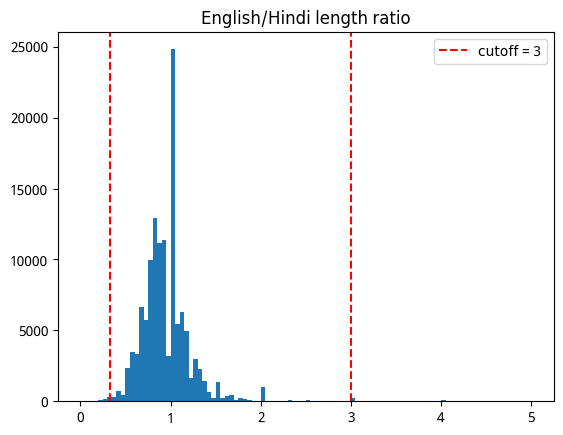

In [10]:
# Length ratio histogram

# Element-wise division of the two Series.
# en_lens and hi_lens both from same df so same index. Pandas aligns by index
# Results in series where each value is len(english) / len(hindi) for that row
ratios = (en_lens / hi_lens).replace([float('inf'), -float('inf')], float('nan')).dropna()
# dropna to drop the NaNs
# if hi_lens = 0, convert to NaN and then drop that

# Histogram clipped to 0, 5 so long tail doesn't dominate
plt.hist(ratios, bins=100, range=(0, 5))

# Two vertical lines. Either side = 3x other side
# one label else legend shows identical entries
plt.axvline(3, color='red', linestyle='--', label='cutoff = 3')
plt.axvline(1/3, color='red', linestyle='--')

# Title + show legend + render
plt.title('English/Hindi length ratio'); plt.legend(); plt.show()

# Preprocessing & Tokenization

In [11]:
# Remove English nulls
df.dropna(subset=['english_sentence', 'hindi_sentence'], inplace=True)
df.shape # shape returns 127605 — two rows with nulls removed

# Remove all duplicates
df.drop_duplicates(subset=['english_sentence', 'hindi_sentence'], inplace=True)

In [12]:
# Clean English


# Takes a raw string, returns a clean string
def clean_english(text):
    text = text.lower() # 1. Lowercase everything
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # 2. Replace URL with single space
    text = re.sub(r'<.*?>', ' ', text) # 3. replace HTML tag with a space
    text = re.sub(r'\s+', ' ', text) # 4. Collapse any run of whitespace to one space
    text = text.strip() # 5. strip leading/trailing whitespaces
    return text

# Run clean_english on every row
df['english_sentence'] = df['english_sentence'].apply(clean_english)

In [13]:
# Clean Hindi

def clean_hindi(text):
    # Note: no .lower() because Devanagari has no case
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # 1. Replace URL with single space
    text = re.sub(r'<.*?>', ' ', text) # 2. replace HTML tag with a space
    text = re.sub(r'\s+', ' ', text) # 3. Collapse any run of whitespace to one space
    text = text.strip() # 4. strip leading/trailing whitespaces
    return text

# Run clean_hindi on every row
df['hindi_sentence'] = df['hindi_sentence'].apply(clean_hindi)

In [14]:
# Tokenize

# new column en_tokens on df = nltk.word_tokenize on every cell of english_sentence
# Each call takes a string and returns a list of strings.
# Resulting series has lists for values
df['en_tokens'] = df['english_sentence'].apply(nltk.word_tokenize)

# Trivial tokenize needs lang
df['hi_tokens'] = df['hindi_sentence'].apply(indic_tokenize.trivial_tokenize, lang='hi')


In [15]:
# Get five random tokens

# Take both columns of tokens, sample 5 rows, set random seed
df[['en_tokens', 'hi_tokens']].sample(5, random_state=42)

,en_tokens,hi_tokens
16709,"[.men, (, giver, ), to, facilitate, :, ), :, )...","[·, पुरुष, (, Giver, ), को, सहूलियत, ☻☻☻☻, ☺, ..."
44058,"[and, actually, tell, them, what, they, are, d...","[और, उन, लोगों, को, बता, रहा, था, कि, वो, लोग,..."
19519,"[the, fabric, ,, parachute, and, everything, -...","[कपडा, ,, अवतरण, छतरी, तथा, अन्य, सभी, सामाग्र..."
28886,"[china, and, india, infact, they, are, untouch...","[चीन, और, भारत, हालांकि, इसके, प्रावधानों, से,..."
86193,"[it, is, the, first, infrastructure, project, ...","[यह, बुनियादी, संरचना, की, पहली, परियोजना, है,..."


In [16]:
# Filter on token counts
# we want a max of 30 tokens on both sides with a lower bound of 1
# keep rows with ratio >= 1/3 & ratio <= 3

print(f"Old shape: {df.shape}")

# Get a series of English token counts
en_len = df['en_tokens'].str.len()
# Ditto for hindi
hi_len = df['hi_tokens'].str.len()

# Create masks applying each condition
mask_A = (en_len >= 1) & (en_len <= 30)
mask_B = (hi_len >= 1) &  (hi_len <= 30)
ratio = en_len/hi_len
mask_C = (ratio >= 1/3) & (ratio <= 3)

# Combine the masks to create one new mask with all the conditions assumed
combined_mask = mask_A & mask_B & mask_C
df = df[combined_mask] # Pandas returns a new DataFrame with only the rows where the mask is True
df = df.reset_index(drop=True) # Clean up indexing

# Check new shape
print(f"New shape : {df.shape}")

# Get new en_len and hi_len after filtering
en_len_after = df['en_tokens'].str.len()
hi_len_after = df['hi_tokens'].str.len()


Old shape: (124825, 5)
New shape : (101834, 5)


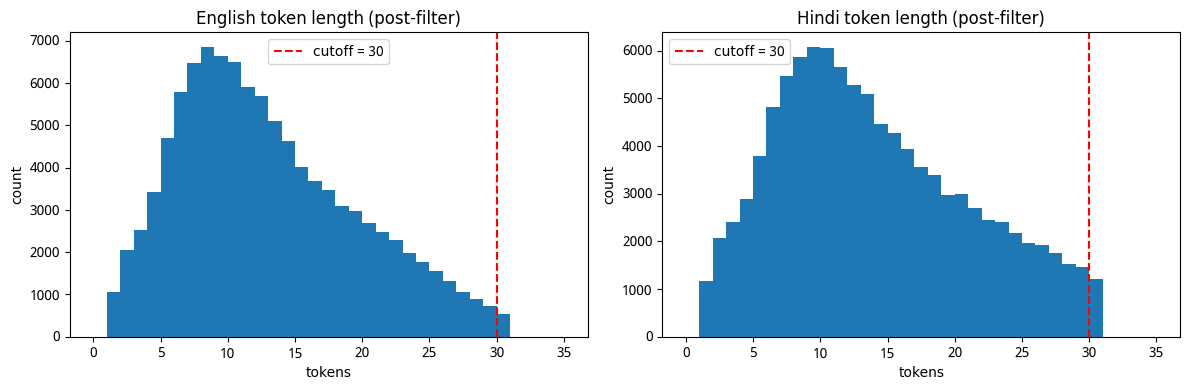

English:
count    101834.000000
mean         12.489895
std           6.617049
min           1.000000
25%           7.000000
50%          11.000000
75%          17.000000
max          30.000000
Name: en_tokens, dtype: float64
Hindi:
count    101834.000000
mean         13.530029
std           7.154257
min           1.000000
25%           8.000000
50%          12.000000
75%          19.000000
max          30.000000
Name: hi_tokens, dtype: float64


In [17]:
# Check:
# 1. Histogram of post-filtering en_len and hi_len

# axes[0] is left plot, axes[1] is right plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left plot: english
# bins=35 — divide x into 35 equal bins.
# Tokens should be between 1 and 30 now
axes[0].hist(en_len_after, bins=35, range=(0, 35))
axes[0].axvline(30, color='red', linestyle='--', label='cutoff = 30')
axes[0].set_title('English token length (post-filter)')
axes[0].set_xlabel('tokens'); axes[0].set_ylabel('count');
axes[0].legend() # legend takes any label= and creates a legend box

# right plot: hindi
axes[1].hist(hi_len_after, bins=35, range=(0, 35))
axes[1].axvline(30, color='red', linestyle='--', label='cutoff = 30')
axes[1].set_title('Hindi token length (post-filter)')
axes[1].set_xlabel('tokens'); axes[1].set_ylabel('count');
axes[1].legend()

plt.tight_layout();
plt.show()

# 2. Describe
# gives count (rows survived), mean, std, min, percentiles, max
print(f"English:\n{en_len_after.describe()}")
print(f"Hindi:\n{hi_len_after.describe()}")

# Vocabulary & Dataset/Dataloader

Four steps:
raw text -> tokens [vocab] -> integer IDs [Dataset] -> padded batch tensors [collate_fn -> DataLoader]

Creation order:

split -> vocab -> dataset -> DataLoader

Split first. Build vocab from train-only. Test tokens not in train are <unk>.

Shuffle df with random_state for reproducibility, then slice. Use iloc.

In [18]:
# Set constants
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3


In [19]:
# Train/test split

# Shuffle rows AND reset index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Compute split point
split_idx = int(len(df) * 0.9)

# Slice with iloc
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]
# iloc is integer-position-based, loc is label-based.

# Print
print(f"Sum: {len(train_df) + len(test_df)}, original: {len(df)}")


Sum: 101834, original: 101834


In [20]:
# Vocab — capped at 15k as per Zipf's law. Want it larger for bigger datasets like IITB later
class Vocab():
    def __init__(self, token_lists, max_size=20000):
        # Takes iterable of token lists (from train_df['en_tokens'])
        # counts frequencies, takes top N tokens (N = max_size - 4 for the four specials)

        # Initialize integer-to-string list with four special tokens
        self.itos = ['<pad>', '<sos>', '<eos>', '<unk>']

        counter = Counter()

        # Tokens is the token list for one sentence
        for tokens in token_lists:
            # Increments the count for every token in the list
            counter.update(tokens)

        # .most_common(max_size - 4) — returns top max_size-4 tokens by count
        # as a list of (token, count) tuples
        # list comprehension to unpack each token into top tokens list
        top_tokens = [tok for tok, _ in counter.most_common(max_size - 4)]

        # add the top tokens to the itos list
        self.itos.extend(top_tokens)

        # Build reverse mapping. enumerate(self.itos) gives index, token tuples..
        # Dict comprehension flips each pair: key is token, value is index
        # string to integer. Itos is given an ID, what is its token?
        # Stoi is given a string, and answers what is its ID?
        # Stoi is a dict because there is no ordering to index into
        # Itos is a list because IDs are contiguous integers 0 to N-1
        # itos[stoi[token]] == token and stoi[itos[id]] == id
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

    def encode(self, tokens):
        # Takes a list of token strings, returns a list of integer IDs. <unk> for token not in stoi
        unk_id = self.stoi['<unk>']
        return [self.stoi.get(tok, unk_id) for tok in tokens]

    def decode(self, ids):
        # Takes list of integer IDs, returns a list of token strings. Inverse of encode.
        return [self.itos[id] for id in ids]

    def __len__(self):
        # Returns vocab size
        return len(self.itos)

In [21]:
# Build English and Hindi Vocabulary
en_vocab = Vocab(train_df['en_tokens'])
hi_vocab = Vocab(train_df['hi_tokens'])

# Check
print(len(hi_vocab), len(en_vocab))
print(hi_vocab.itos[:6])
print(hi_vocab.stoi['<pad>'])

tokens = train_df.iloc[0]['hi_tokens'];
print(tokens);
print(hi_vocab.decode(hi_vocab.encode(tokens)))


20000 20000
['<pad>', '<sos>', '<eos>', '<unk>', 'के', '.']
0
['मैंने', 'पाकिस्तान', 'खुद', 'जाने', 'का', 'फैसला', 'किया', '.']
['मैंने', 'पाकिस्तान', 'खुद', 'जाने', 'का', 'फैसला', 'किया', '.']


In [22]:
# Translation Dataset
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, df, hi_vocab, en_vocab):
        self.hi_vocab = hi_vocab
        self.en_vocab = en_vocab

        # store tokens lists from pandas Series to Python list for Hindi
        self.hi_token_lists = df['hi_tokens'].tolist()

        # Ditto English
        self.en_token_lists = df['en_tokens'].tolist()

    def __len__(self):
        return len(self.hi_token_lists) # same length for both languages

    def __getitem__(self, i):
        # for row i, need to give the hindi and english sequence.
        # Each tensor is the row's tokens but..
        # Encoded to IDs, wrapped with <sos> and <eos>, and converted to torch.Tensor

        # Encode tokens to IDs
        hi_encoded = self.hi_vocab.encode(self.hi_token_lists[i])
        en_encoded = self.en_vocab.encode(self.en_token_lists[i])

        # Wrap with <sos> and <eos> (start of sentence token, end of sentence token)
        hi_wrapped = [SOS_IDX] + hi_encoded + [EOS_IDX]
        en_wrapped = [SOS_IDX] + en_encoded + [EOS_IDX]

        # Convert to torch.Tensor
        # nn.Embedding needs input to be int64 (long)
        hi_tensor = torch.tensor(hi_wrapped, dtype=torch.long)
        en_tensor = torch.tensor(en_wrapped, dtype=torch.long)

        # Return!
        return (hi_tensor, en_tensor)


In [23]:
# Build train and test datasets
train_dataset = TranslationDataset(train_df, hi_vocab, en_vocab)
test_dataset = TranslationDataset(test_df, hi_vocab, en_vocab)
print(f"Train dataset length: {len(train_dataset)}")
print(f"Test dataset length: {len(test_dataset)}")
hi_t, en_t = train_dataset[0]
print(f"Datatype and shape of first piece of train data: {hi_t.dtype}, {hi_t.shape}")
print(f"SOS and EOS check {hi_t[0].item()}, {hi_t[-1].item()}")

Train dataset length: 91650
Test dataset length: 10184
Datatype and shape of first piece of train data: torch.int64, torch.Size([10])
SOS and EOS check 1, 2


In [24]:
# Function to take the list of (hi_tensor, en_tensor) and create a batch with padding to make the batch rectangular

# This solves the variable-length problem
def collate_fn(batch):
    # batch is a list of length batch_size, where each element is a tuple from the Dataset
    # Must return two batched, padded tensors
    # hi_batch: shape of (batch_size, max_hi_len_in_batch) every row is a Hindi sequence padded to the longest one in this batch.
    # en_batch: shape of (batch_size, max_en_len_in_batch) — same as hindi
    # Each batch is padded to the max length in the batch, not dataset, to avoid wasting compute

    # Separate the tuples into two lists
    hi_list, en_list = zip(*batch)

    # Pad each list
    hi_padded = pad_sequence(hi_list, batch_first=True, padding_value=PAD_IDX)
    en_padded = pad_sequence(en_list, batch_first=True, padding_value=PAD_IDX)

    # Return!
    return (hi_padded, en_padded)

In [25]:
# Create DataLoaders
BATCH_SIZE = 64
# NUM_WORKERS = 2 if device.type == "cuda" else 0
NUM_WORKERS = 0
PIN_MEMORY = device.type == "cuda"
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=NUM_WORKERS,
                          collate_fn=collate_fn,
                          pin_memory=PIN_MEMORY)

test_loader = DataLoader(dataset=test_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS,
                          collate_fn=collate_fn,
                          pin_memory=PIN_MEMORY)

In [26]:
# Check that DataLoaders are correct
hi_batch, en_batch = next(iter(train_loader))
print(f"Hindi batch shape: {hi_batch.shape}\n and dtype: {hi_batch.dtype}")
print(f"Ditto — English batch shape: {en_batch.shape}\n and dtype: {en_batch.dtype}")
print(f"First sentence:\n{hi_batch[0]}") # first sentence of the batch should start with 1s (SOS) and end with 2s (EOS) or 0s (PAD)

Hindi batch shape: torch.Size([64, 28])
 and dtype: torch.int64
Ditto — English batch shape: torch.Size([64, 31])
 and dtype: torch.int64
First sentence:
tensor([  1,  80,   3,  30, 141,   3,   7, 139,   7,  17, 149,   3,  86,  47,
          2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0])


# **Phase A** Vanilla Seq2Seq (encoder, decoder, training, greedy decode)

Encoder compresses Hindi sentence into one fixed vector

->

Decoder takes the encoder's final hidden state as its initial hidden state to create English.

In [27]:
# Create the Encoder class
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.GRU(emb_dim, hidden_dim, num_layers=1, batch_first=True)

    def forward(self, hi_batch):
        out = self.embedding(hi_batch)
        out, hidden = self.rnn(out) # returns (outputs, hidden). No hidden state passed in -> defaults to zeros.
        return hidden

In [28]:
# Create the Decoder class

# Decoder processes one timestep per call, not the entire loop (unlike GRU)
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx) # English embedding
        self.rnn = nn.GRU(emb_dim, hidden_dim, num_layers=1, batch_first=True) # same config as encoder GRU
        self.fc = nn.Linear(hidden_dim, vocab_size, bias=True) # Project 512 dim output to ~20000 logits of English vocab
        # Bias = true so the model can assign higher logits to common tokens
        # Skipping dropout to see bottleneck behavior

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1) # input token is of shape (BATCH_SIZE), unsqueeze to get 1 for seq_len. New dim is at position 1
        # Embed the token
        out = self.embedding(input_token) # output shape is (B, 1, emb_dim)
        out, new_hidden = self.rnn(out, hidden)
        # out shape now is (B, 1, hidden_dim)
        # new_hidden shape is (1, B, hidden_dim)
        out = out.squeeze(1) # squeeze off seq_len. We want (B, hidden_dim) for linear layer
        logits = self.fc(out) # turns (B, hidden_dim) to (B, vocab_size)
        return logits, new_hidden



In [ ]:
# Create the overall Seq2Seq class
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, hi_batch, en_batch, teacher_forcing_ratio):
        B = hi_batch.shape[0] # get batch size
        en_L = en_batch.shape[1] # English seq length from second dim of en_batch
        vocab_size = self.decoder.fc.out_features # see vocab size from decoder's linear layer
        device = hi_batch.device
        output_buffer = torch.zeros(B, en_L - 1, vocab_size, device=device)

        hidden = self.encoder(hi_batch) # shape (1, B, hidden_dim)
        decoder_input = en_batch[:, 0] # init decoder input as <sos> — this is just a tensor of 64 ones (takes all batch elements, but only position zero)

        # Loop through each timestep t
        for t in range(en_L - 1):
            # Call decoder, reassign hidden
            logits, hidden = self.decoder(decoder_input, hidden)

            # Store logits in buffer at slot t(imestep)
            output_buffer[:, t, :] = logits

            # Coin flip + pick next input
            use_tf = torch.rand(1).item() < teacher_forcing_ratio
            decoder_input = en_batch[:, t + 1] if use_tf else logits.argmax(dim=-1)

        return output_buffer

    @torch.inference_mode()
    def greedy_decode(self, hi_batch, max_len=50):
        # Read B and device from hi_batch
        B = hi_batch.shape[0]
        device = hi_batch.device

        # Encode
        hidden = self.encoder(hi_batch)

        # Init decoder input as <sos> for every batch element
        decoder_input = torch.full((B,), SOS_IDX, dtype=torch.long, device=device)

        # Pre-allocate the output buffer
        generated = torch.zeros(B, max_len, dtype=torch.long, device=device)

        for t in range(max_len):
            # Run decoder once
            logits, hidden = self.decoder(decoder_input, hidden)

            # Take arg max
            prediction = logits.argmax(dim=-1)

            # Store in buffer
            generated[:, t] = prediction

            # Feed back
            decoder_input = prediction

        return generated



In [ ]:
# Create helper functions for training
def train_one_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for hi_batch, en_batch in tqdm(train_loader):
        hi_batch, en_batch = hi_batch.to(device), en_batch.to(device)

        optimizer.zero_grad()

        logits = model(hi_batch, en_batch, teacher_forcing_ratio=0.5) # Shape (B, en_L - 1, vocab_size)
        targets = en_batch[:, 1:] # shape (B, en_L - 1) — model predicts at position t when given 0-(t-1), so targets are 1-(en_L-1)
        # 1: — 1 to the end, dropping position zero. Stays 2D bc its a slice

        loss = loss_fn(
            logits.reshape(-1, logits.shape[-1]), # convert to shape (B*T, V)
            targets.reshape(-1) # then convert to (B*T)
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping

        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(train_loader)


In [ ]:
def eval_one_epoch(model, test_loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.inference_mode():
        for hi_batch, en_batch in tqdm(test_loader):
            hi_batch, en_batch = hi_batch.to(device), en_batch.to(device)
            logits = model(hi_batch, en_batch, teacher_forcing_ratio=0)
            targets = en_batch[:, 1:]
            loss = loss_fn(
                logits.reshape(-1, logits.shape[-1]), # convert to shape (B*T, V)
                targets.reshape(-1) # then convert to (B*T)
                )
            total_loss += loss.item()
    return total_loss / len(test_loader)


In [ ]:
# Training!

# Hyperparameters
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
CHECKPOINT_PATH = '/content/drive/MyDrive/rnn-translator/best_model.pth' # .pt or .pth?

In [ ]:
# Create model
encoder = Encoder(len(hi_vocab), 256, 512, PAD_IDX) # build encoder
decoder = Decoder(len(en_vocab), 256, 512, PAD_IDX) # build decoder
model = Seq2Seq(encoder, decoder).to(device) # combine to create the model!

# Create loss fn and optimizer
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
# Driver loop
best_test_loss = float('inf')
train_losses, test_losses = [], []

for epoch in range(NUM_EPOCHS):
    # Train and test one epoch
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    test_loss = eval_one_epoch(model, test_loader, loss_fn)

    # Add to lists
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # Save the model
    saved = ""
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved = " (saved)"

    # Print
    print(f"Epoch {epoch+1:2d}: train={train_loss:.4f}  test={test_loss:.4f}{saved}")

  0%|          | 0/1433 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

Epoch  1: train=5.7242  test=5.6466 (saved)


  0%|          | 0/1433 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

Epoch 14: train=2.6931  test=5.7805


  0%|          | 0/1433 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

Epoch 15: train=2.6422  test=5.8553


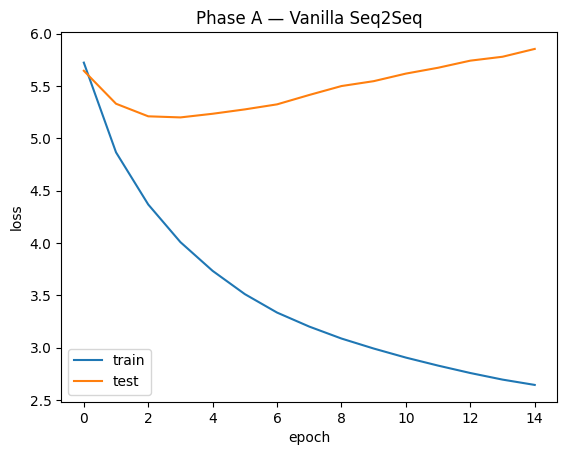

In [ ]:
# Plot loss curve
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Phase A — Vanilla Seq2Seq')
plt.show()

In [ ]:
# Translate method
def translate(model, sentence, hi_vocab, en_vocab, device, max_len=50):
    # Sentence is a raw Hindi string
    # returns a raw English string
    # Essentially the data pipeline but for a single input at inference time

    model.eval()
    with torch.inference_mode():
        # Tokenize hindi string
        tokens = indic_tokenize.trivial_tokenize(sentence, lang='hi')

        # Encode tokens to IDs
        ids = hi_vocab.encode(tokens)

        # Wrap with <sos> and <eos>
        wrapped = [SOS_IDX] + ids + [EOS_IDX]

        # Convert to tensor, add batch dim
        # torch.tensor(wrapped, dtype=torch.long) # gives (hi_L,)
        hi_tensor = torch.tensor(wrapped, dtype=torch.long).unsqueeze(0).to(device) # unsqueeze to add leading dim of 1 shape

        # Call model
        generated = model.greedy_decode(hi_tensor, max_len=max_len)[0].cpu().tolist()

        # Truncate at <eos>, decode, and join

        for idx, t_id in enumerate(generated):
            if t_id == EOS_IDX:
                generated = generated[:idx]
                break

        en_tokens = en_vocab.decode(generated)

        final_str = nltk.tokenize.treebank.TreebankWordDetokenizer().detokenize(en_tokens)

        return final_str


In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH))

<All keys matched successfully>

In [ ]:
# Test translate

test_sentences = [
    "मैं घर जा रहा हूँ",                # "I am going home" — short, very common words
    "वह एक अच्छा लड़का है",             # "He is a good boy" — short copular sentence
    "मुझे हिंदी सीखना अच्छा लगता है",    # "I like learning Hindi" — medium length, infinitive form
    "बारिश हो रही है",                  # "It is raining" — short weather expression
]

for hi in test_sentences:
    # Call translate (returns a single English string for this Hindi sentence)
    en = translate(model, hi, hi_vocab, en_vocab, device)

    # Print Hindi input and the model's English output stacked, so it's easy to scan
    print(f"HI: {hi}")
    print(f"EN: {en}")

    # Blank line between examples for readability
    print()


HI: मैं घर जा रहा हूँ
EN: i 'm home house house i 'm home house

HI: वह एक अच्छा लड़का है
EN: he is a <unk> <unk> <unk> <unk> <unk> <unk> <unk>

HI: मुझे हिंदी सीखना अच्छा लगता है
EN: i have to to the the of the , the hindi , ,

HI: बारिश हो रही है
EN: the the the the <unk> is the <unk>



In [ ]:
predictions = []
references = []
for hi, en in tqdm(zip(test_df['hindi_sentence'], test_df['english_sentence'])):
    predictions.append(translate(model, hi, hi_vocab, en_vocab, device=device))
    references.append(en)

result = sacrebleu.corpus_bleu(predictions, [references])
print(result.score)

1.946431553261839


# **Phase B** Add Bahdanau attention (bidirectional encoder, attention module, updated decoder)

In [29]:
class BiEncoder(nn.Module):
    def __init__(self,
                 input_dim, # size of hindi vocab
                 embed_dim,
                 enc_hidden_size,
                 dec_hidden_size,
                 dropout_p,
                 pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=pad_idx)
        self.embed_dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(embed_dim, enc_hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.bridge = nn.Linear(2 * enc_hidden_size, dec_hidden_size)

    def forward(self,
                src,
                src_lengths):
        # src is padding token ids
        # src_lengths is unpadded length of each sequence

        # Embed the sequence
        embedded = self.embedding(src)

        # Dropout
        embedded = self.embed_dropout(embedded)

        # Pack
        packed = pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)

        # Go thru GRU
        packed_outputs, final_hidden = self.gru(packed)

        encoder_outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)

        # Go thru bridge
        decoder_init = torch.tanh(self.bridge(torch.cat([final_hidden[0], final_hidden[1]], dim=1))).unsqueeze(0)


        return encoder_outputs, decoder_init

In [30]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hidden_size, dec_hidden_size, attn_dim):
        super().__init__()

        # Project decoder state into comparison space
        self.W_a = nn.Linear(dec_hidden_size, attn_dim, bias=False)

        # Project each encoder output into comparison space
        self.U_a = nn.Linear(2 * enc_hidden_size, attn_dim, bias=False)

        # Collapses the comparison vector to a scalar score
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask):
        # project decoder state, unsqueeze to broadcast over source length dimension
        query = self.W_a(decoder_hidden).unsqueeze(1)

        # Project encoder outputs
        keys = self.U_a(encoder_outputs)

        # Sum and tanh
        energy = torch.tanh(query + keys)

        # Collapse to scores
        scores = self.v(energy).squeeze(-1)

        # Mask padded positions
        scores = scores.masked_fill(~src_mask, -1e9)

        # Softmax
        attn_weights = torch.softmax(scores, dim=1)

        # Compute context vector
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return (context, attn_weights)


In [31]:
class AttnDecoder(nn.Module):
    def __init__(self,
                 output_dim,
                 embed_dim,
                 enc_hidden_size,
                 dec_hidden_size,
                 attn_dim,
                 dropout_p,
                 pad_idx):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=pad_idx) # target token embeddings
        self.embed_dropout = nn.Dropout(dropout_p) # regularization
        self.attention = BahdanauAttention(enc_hidden_size, dec_hidden_size, attn_dim) # implements attention
        self.gru = nn.GRU(embed_dim + 2*enc_hidden_size, dec_hidden_size, num_layers=1, batch_first=True) # decoder recurrence, input size is enlarged bc of bidirectional encoder
        self.out_dropout = nn.Dropout(dropout_p) # regularization
        self.fc_out = nn.Linear(dec_hidden_size, output_dim) # Project to vocab logits

    def forward(self,
                target_toks,
                encoder_outputs,
                decoder_init_hidden,
                src_mask,
                teacher_forcing_ratio):
        # Preallocate output buffers
        B = target_toks.size(0)
        all_logits = torch.zeros(B, target_toks.size(1) - 1, self.output_dim, device=target_toks.device)
        all_attn_weights = torch.zeros(B, target_toks.size(1) - 1, encoder_outputs.size(1), device=target_toks.device)

        input_token = target_toks[:, 0] # <sos> column shape (B,)
        hidden = decoder_init_hidden

        for t in range (target_toks.size(1) - 1):
            # Embed each token
            embedded = self.embed_dropout(self.embedding(input_token))

            # Get attention using previous hidden state
            context, attn_weights_t = self.attention(hidden.squeeze(0), encoder_outputs, src_mask)
            # Context is shape (B, enc_hidden_size * 2)

            # Create GRU input by concatenating
            gru_input = torch.cat([embedded, context], dim=1)
            # Go thru GRU
            output, hidden = self.gru(gru_input.unsqueeze(1), hidden) # output shape of (B, 1, dec-hidden_size)

            # Project to vocab
            logits_t = self.fc_out(self.out_dropout(output.squeeze(1))) # gives (B, output_dim)

            # Stash outputs
            all_logits[:, t] = logits_t
            all_attn_weights[:, t] = attn_weights_t

            # Teacher forcing choice
            if random.random() < teacher_forcing_ratio:
                input_token = target_toks[:, t + 1] # ground truth
            else:
                input_token = logits_t.argmax(dim=1) # the model's guess

        return (all_logits, all_attn_weights) # returns preds at each step and attn weights for heatmaps

In [32]:
class AttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def forward(self,
                src,
                src_lengths,
                target_toks,
                teacher_forcing_ratio):
        src_mask = (src != self.pad_idx)
        encoder_outputs, decoder_init_hidden = self.encoder(src, src_lengths)
        return self.decoder(target_toks, encoder_outputs, decoder_init_hidden, src_mask, teacher_forcing_ratio)

In [33]:
def attn_collate_fn(batch):
    src_tensors, tgt_tensors = zip(*batch)
    src_lengths = torch.tensor([tensor.size(0) for tensor in src_tensors])
    padded_src = pad_sequence(src_tensors, batch_first=True, padding_value=PAD_IDX)
    padded_tgt = pad_sequence(tgt_tensors, batch_first=True, padding_value=PAD_IDX)
    return (padded_src, src_lengths, padded_tgt)

In [34]:
def attn_train_one_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for hi_batch, hi_batch_lens, en_batch in tqdm(train_loader):
        hi_batch, en_batch = hi_batch.to(device), en_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(hi_batch, hi_batch_lens, en_batch, teacher_forcing_ratio=0.5)
        targets = en_batch[:, 1:]
        loss = loss_fn(
            logits.reshape(-1, logits.shape[-1]),
            targets.reshape(-1)
            )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


In [35]:
def attn_eval_one_epoch(model, test_loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.inference_mode():
        for hi_batch, hi_batch_lens, en_batch in tqdm(test_loader):
            hi_batch, en_batch = hi_batch.to(device), en_batch.to(device)
            logits, _ = model(hi_batch, hi_batch_lens, en_batch, teacher_forcing_ratio=0.0)
            targets = en_batch[:, 1:]
            loss = loss_fn(
                logits.reshape(-1, logits.shape[-1]), # convert to shape (B*T, V)
                targets.reshape(-1) # then convert to (B*T)
                )
            total_loss += loss.item()
    return total_loss / len(test_loader)

In [36]:
# Create new dataloaders with attn_collate_fn
attn_train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=NUM_WORKERS,
                          collate_fn=attn_collate_fn,
                          pin_memory=PIN_MEMORY)

attn_test_loader = DataLoader(dataset=test_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS,
                          collate_fn=attn_collate_fn,
                          pin_memory=PIN_MEMORY)

In [48]:
# Setup model, loss, and optimizer
attn_encoder = BiEncoder(input_dim=len(hi_vocab),
                      embed_dim=256,
                      enc_hidden_size=512,
                      dec_hidden_size=512,
                      dropout_p=0.3,
                      pad_idx=PAD_IDX)
attn_decoder = AttnDecoder(output_dim=len(en_vocab),
                          embed_dim=256,
                          enc_hidden_size=512,
                          dec_hidden_size=512,
                          attn_dim=512,
                          dropout_p=0.3,
                          pad_idx=PAD_IDX)
attn_model = AttnSeq2Seq(attn_encoder, attn_decoder, pad_idx=PAD_IDX).to(device)

attn_optimizer = torch.optim.AdamW(attn_model.parameters(), lr=1e-3, weight_decay=1e-4)

attn_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.2, ignore_index=PAD_IDX)


In [49]:
NUM_EPOCHS = 10

# Train
attn_train_history, attn_test_history = [], []
attn_best_test_loss = float('inf')

CHECKPOINT_PATH = '/content/drive/MyDrive/rnn-translator/best_attn_model.pth'
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

for epoch in range(NUM_EPOCHS):
    # Train and test one epoch
    attn_train_loss = attn_train_one_epoch(attn_model, attn_train_loader, attn_optimizer, attn_loss_fn)
    attn_test_loss = attn_eval_one_epoch(attn_model, attn_test_loader, attn_loss_fn)

    # Add to lists
    attn_train_history.append(attn_train_loss)
    attn_test_history.append(attn_test_loss)

    # Save the model
    saved = ""
    if attn_test_loss < attn_best_test_loss:
        attn_best_test_loss = attn_test_loss
        torch.save(attn_model.state_dict(), CHECKPOINT_PATH)
        saved = " (saved)"

    # Print
    print(f"Epoch {epoch+1:2d}: attn_train={attn_train_loss:.4f}  attn_test={attn_test_loss:.4f}{saved}")


  0%|          | 0/1433 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

Epoch  1: attn_train=6.8514  attn_test=6.6071 (saved)


  0%|          | 0/1433 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

Epoch  9: attn_train=5.6341  attn_test=6.2216 (saved)


  0%|          | 0/1433 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

Epoch 10: attn_train=5.5960  attn_test=6.2149 (saved)


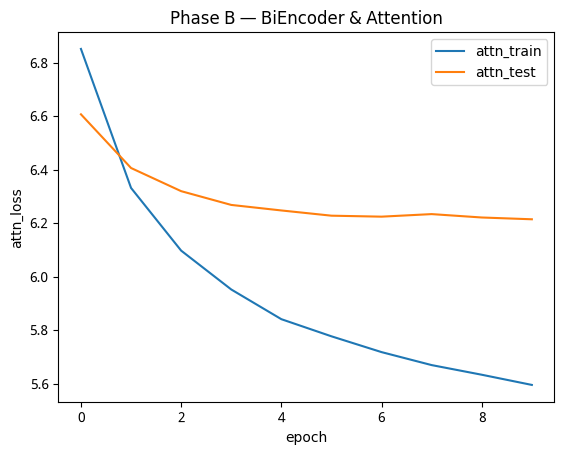

In [50]:
# Plot loss curve
plt.plot(attn_train_history, label='attn_train')
plt.plot(attn_test_history, label='attn_test')
plt.xlabel('epoch')
plt.ylabel('attn_loss')
plt.legend()
plt.title('Phase B — BiEncoder & Attention')
plt.show()

In [51]:
def attn_greedy_decode(model, src, max_len, sos_idx, eos_idx, pad_idx, device):
    model.eval()
    with torch.inference_mode():
        src_length = src.size(0) # length of src tensor

        src_lengths = torch.tensor([src_length]) # wrap into cpu tensor

        # add batch dim
        src = src.unsqueeze(0).to(device)

        # Run encoder
        encoder_outputs, hidden = model.encoder(src, src_lengths)

        src_mask = (src != pad_idx) # create source mask

        input_token = torch.tensor([sos_idx], device=device) # create input token
        predicted_ids = []
        attn_history = []

        for t in range(max_len):
            embedded = model.decoder.embedding(input_token) # embed the input token

            # Compute attention using previous hidden state
            context, attn_weights_t = model.decoder.attention(hidden.squeeze(0), encoder_outputs, src_mask)

            # Concatenate embedding and context to run in GRU
            gru_input = torch.cat([embedded, context], dim=1)
            output, hidden = model.decoder.gru(gru_input.unsqueeze(1), hidden)

            # project the GRU output to vocab logits
            logits = model.decoder.fc_out(output.squeeze(1))

            # The next predicted token ID for this timestep
            next_token = logits.argmax(dim=1)

            # add the predicted id and attention vector to output lists
            predicted_ids.append(next_token.item())
            attn_history.append(attn_weights_t.squeeze(0)) # squeeze removes batch dim

            if next_token.item() == eos_idx:
                break # if emitted eos, stp generating

            input_token = next_token # else, feed this prediction to the next iteration

        # combine per step attention vectors into a 2d tensor
        attn_matrix = torch.stack(attn_history, dim=0)

        return predicted_ids, attn_matrix

In [52]:
def plot_attention(src_tokens, pred_tokens, attn_matrix, title=None):
    attn_np = attn_matrix.detach().cpu().numpy() # convert attention tensor to numpy
    attn_np = attn_np[:len(pred_tokens), :len(src_tokens)] # match token counts we have in case of overallocation
    fig, ax = plt.subplots(
        figsize=(max(6, len(src_tokens) * 0.6),
                 max(4, len(pred_tokens) * 0.5))
    )
    im = ax.imshow(attn_np, cmap='viridis', aspect='auto')

    # one tick per source position labeled with the hindi token for the x axis
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')

    # same but english and y axis
    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens)

    # axis labels for clarity
    ax.set_xlabel('Source (Hindi)')
    ax.set_ylabel('Predicted (English)')

    if title:
        ax.set_title(title)

    # colorbar showing what the colors mean
    plt.colorbar(im, ax=ax, label='Attention weight')

    plt.tight_layout()
    plt.show()

In [53]:
def attn_translate(model, sentence, hi_vocab, en_vocab, device, max_len):
    model.eval()
    with torch.inference_mode():
        tokens = indic_tokenize.trivial_tokenize(sentence, lang='hi')
        ids = hi_vocab.encode(tokens)
        wrapped = [SOS_IDX] + ids + [EOS_IDX]
        hi_tensor = torch.tensor(wrapped, dtype=torch.long).to(device)
        predicted_ids, attn_matrix = attn_greedy_decode(model=model,
                                                        src=hi_tensor,
                                                        max_len=max_len,
                                                        sos_idx=SOS_IDX,
                                                        eos_idx=EOS_IDX,
                                                        pad_idx=PAD_IDX,
                                                        device=device)

        for idx, t_id in enumerate(predicted_ids):
            if t_id == EOS_IDX:
                predicted_ids = predicted_ids[:idx]
                attn_matrix = attn_matrix[:idx]
                break

        en_tokens = en_vocab.decode(predicted_ids)
        en_string = nltk.tokenize.treebank.TreebankWordDetokenizer().detokenize(en_tokens)

        src_tokens = ['<sos>'] + tokens + ['<eos>']

        pred_tokens = en_tokens

        return (en_string, src_tokens, pred_tokens, attn_matrix)


In [54]:
# Load state dict
CHECKPOINT_PATH = '/content/drive/MyDrive/rnn-translator/best_attn_model.pth'
attn_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
attn_model.eval()

AttnSeq2Seq(
  (encoder): BiEncoder(
    (embedding): Embedding(20000, 256, padding_idx=0)
    (embed_dropout): Dropout(p=0.3, inplace=False)
    (gru): GRU(256, 512, batch_first=True, bidirectional=True)
    (bridge): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): AttnDecoder(
    (embedding): Embedding(20000, 256, padding_idx=0)
    (embed_dropout): Dropout(p=0.3, inplace=False)
    (attention): BahdanauAttention(
      (W_a): Linear(in_features=512, out_features=512, bias=False)
      (U_a): Linear(in_features=1024, out_features=512, bias=False)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (gru): GRU(1280, 512, batch_first=True)
    (out_dropout): Dropout(p=0.3, inplace=False)
    (fc_out): Linear(in_features=512, out_features=20000, bias=True)
  )
)

HI: मैं घर जा रहा हूँ
EN: i'm going to leave home


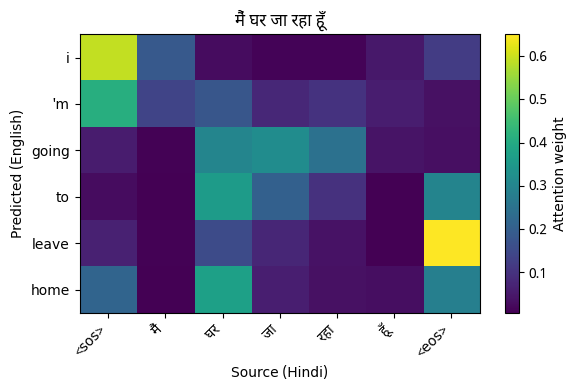


HI: वह एक अच्छा लड़का है
EN: he's a good good


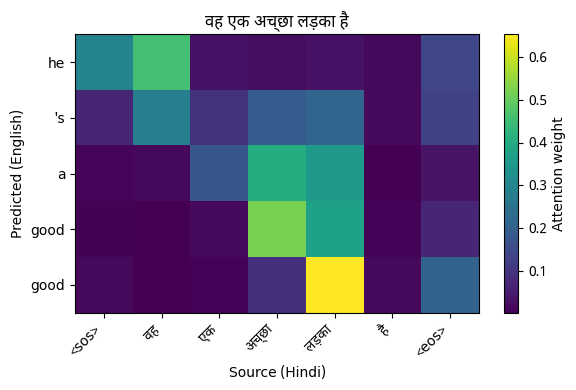


HI: मुझे हिंदी सीखना अच्छा लगता है
EN: i've to learn to learn


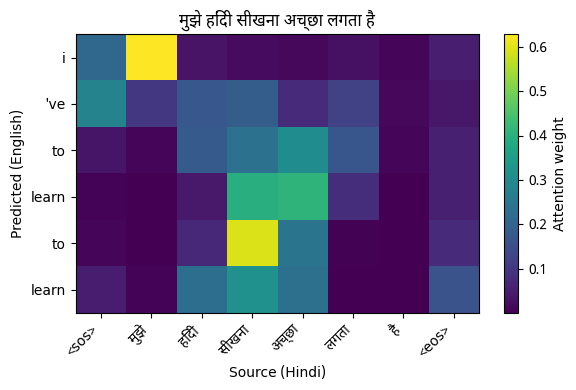


HI: बारिश हो रही है
EN: is the is


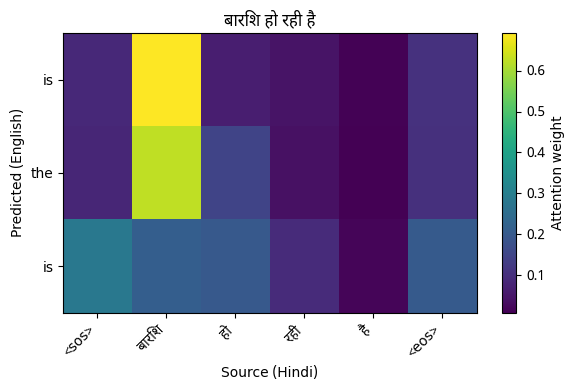


HI: मुझे लगता है कि वह कल बाजार जाएगा
EN: i think that will be a market


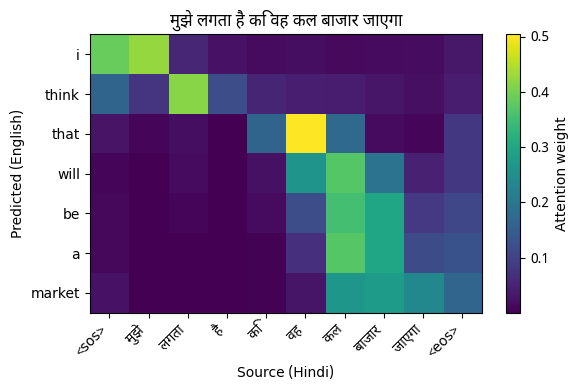

In [55]:
# Test sentences

test_sentences = [
    "मैं घर जा रहा हूँ",                # "I am going home" — short, very common words
    "वह एक अच्छा लड़का है",             # "He is a good boy" — short copular sentence
    "मुझे हिंदी सीखना अच्छा लगता है",    # "I like learning Hindi" — medium length, infinitive form
    "बारिश हो रही है",                  # "It is raining" — short weather expression
    "मुझे लगता है कि वह कल बाजार जाएगा" # "I think he will go to the market tomorrow"
]

for hi in test_sentences:
    # Call translate (returns a single English string for this Hindi sentence)
    en_str, src_toks, pred_toks, attn_matrix = attn_translate(attn_model, hi, hi_vocab, en_vocab, device, max_len=50)

    # Print Hindi input and the model's English output stacked, so it's easy to scan
    print(f"HI: {hi}")
    print(f"EN: {en_str}")

    # Heatmap
    plot_attention(src_toks, pred_toks, attn_matrix, title=hi)

    # Blank line between examples for readability
    print()



In [56]:
# BLEU
predictions = []
references = []
for hi, en in tqdm(zip(test_df['hindi_sentence'], test_df['english_sentence']), total=len(test_df)):
    predictions.append(attn_translate(attn_model, hi, hi_vocab, en_vocab, device=device, max_len=50)[0])
    references.append(en)

result = sacrebleu.corpus_bleu(predictions, [references])
print(result.score)


  0%|          | 0/10184 [00:00<?, ?it/s]

5.627210597890626
